<img src="https://s3-us-west-2.amazonaws.com/public.notion-static.com/7fa59d58-ba42-4de1-840a-e2e31ab9ce3b/ba416d9e-ee4d-4b7a-a9fe-a506333af2b7.png" alt="Abstract Banner" width="100%" height="200" style="object-fit: cover; border-radius: 8px;">

by: Elmar Leonard, Muhammad Rafi Andrianto and Valencia


# **Section 0: Project Initialization**

## **0.1 Importing Library**

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [18]:
DATA_DIR = 'Data' 

df = pd.read_csv("../Dataset/Merged Data/merged.csv")
pd.set_option('display.max_columns', None)
df.shape

(113425, 47)

# **Section 1: Business Explanation**

This section frames the project before any modeling begins: who Olist is, what problem we are solving, for who, how we will approach it, and how we will know it worked. Every claim below is grounded in the preliminary EDA already performed on this dataset not assumptions.


## **1.1 Business Context**

Olist is the largest department store in Brazilian online marketplaces. It does not sell its own products, instead, it operates a multi seller marketplace platform that connects small to medium sized Brazilian businesses to major sales platforms without those sellers needing to build their own e-commerce structure.

Because Olist itself does not control manufacturing or (in most cases) directly control the carrier's performance, its reputation depends entirely on the combined performance of thousands of independent sellers (3,095 in this dataset) and its logistics network, spread across all 27 Brazilian states. A bad experience with any one seller or shipping route reflects on the Olist platform as a whole, since customers experience Olist as one marketplace, not as individual sellers.

This is why **customer satisfaction** functions as Olist's core success metric. Low satisfaction reflected in low review scores can damage a seller's reputation and sales performance, which in turn threatens the health of Olist's whole multi-seller ecosystem. High satisfaction, conversely, drives customer retention and repeat purchases, supporting the platform's long-term sustainability. A satisfied shopper leave positive reviews, which builds trust and drives sales for the platform's independent merchants.

Below are preliminary analysis results that shows that the delivery-satisfaction relationship is real and worth building a project around. The deeper factor analysis (which sellers, regions, product types, and timing windows carry the highest risk) happens in the EDA section using `is_late` as the foundation.

In [25]:
delivered = df[
    (df['order_status'] == 'delivered') &
    df['order_delivered_customer_date'].notna() &
    df['review_score'].notna()
].copy()



delivered['order_delivered_customer_date'] = pd.to_datetime(delivered['order_delivered_customer_date'])
delivered['order_estimated_delivery_date'] = pd.to_datetime(delivered['order_estimated_delivery_date'])
delivered['order_purchase_timestamp'] = pd.to_datetime(delivered['order_purchase_timestamp'])

delivered['is_late'] = (
    delivered['order_delivered_customer_date'].dt.normalize() >
    delivered['order_estimated_delivery_date'].dt.normalize()
)
delivered['delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days

n_rows_before = len(delivered)
delivered = delivered.drop_duplicates(subset='order_id', keep='first').reset_index(drop=True)

print(f"Orders analyzed: {len(delivered):,}")
print(f"Late delivery rate: {delivered['is_late'].mean():.1%}")
print()
print(delivered.groupby('is_late')['review_score'].agg(['mean', 'median', 'count']))

Orders analyzed: 95,824
Late delivery rate: 6.7%

             mean  median  count
is_late                         
False    4.290386     5.0  89443
True     2.270491     1.0   6381


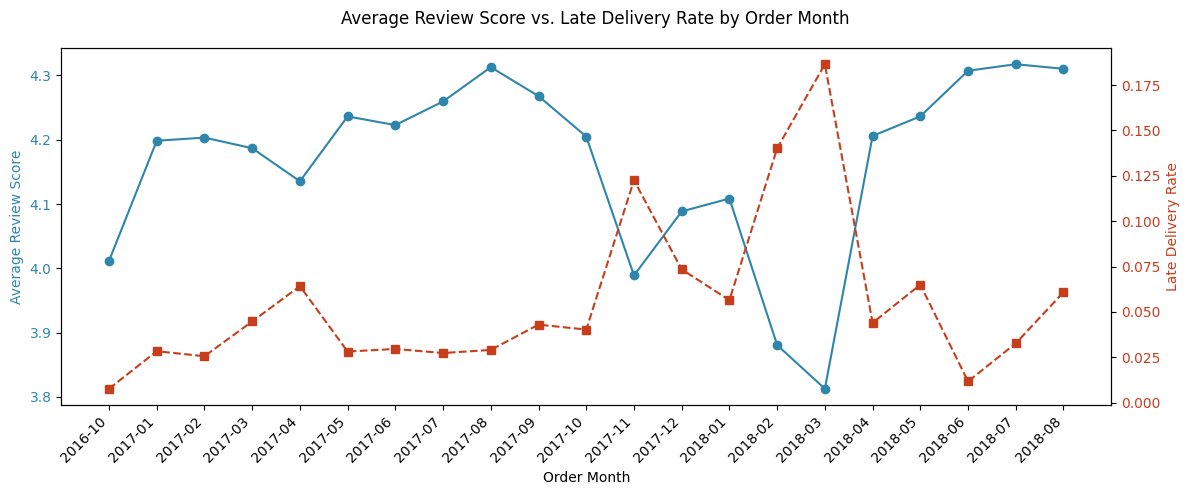

Correlation (monthly late rate vs. monthly avg review score): -0.80


In [20]:
monthly = (
    delivered
    .assign(month=delivered['order_purchase_timestamp'].dt.to_period('M').astype(str))
    .groupby('month')
    .agg(avg_review=('review_score', 'mean'), late_rate=('is_late', 'mean'), n_orders=('review_score', 'size'))
    .reset_index()
)
monthly = monthly[monthly['n_orders'] > 100]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly['month'], monthly['avg_review'], color='#2E86AB', marker='o', label='Avg. Review Score')
ax1.set_ylabel('Average Review Score', color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.set_xlabel('Order Month')
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly['month'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(monthly['month'], monthly['late_rate'], color='#C73E1D', marker='s', linestyle='--', label='Late Delivery Rate')
ax2.set_ylabel('Late Delivery Rate', color='#C73E1D')
ax2.tick_params(axis='y', labelcolor='#C73E1D')

fig.suptitle('Average Review Score vs. Late Delivery Rate by Order Month')
fig.tight_layout()
plt.show()

print(f"Correlation (monthly late rate vs. monthly avg review score): {monthly['avg_review'].corr(monthly['late_rate']):.2f}")


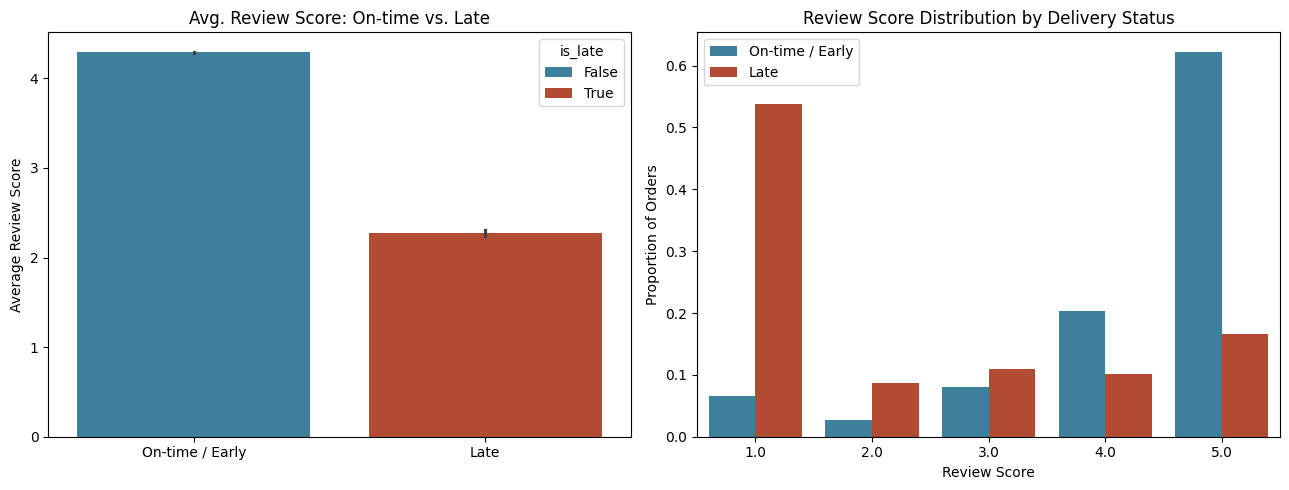

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=delivered, x='is_late', y='review_score', ax=axes[0], hue='is_late', palette=['#2E86AB', '#C73E1D'])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['On-time / Early', 'Late'])
axes[0].set_xlabel('')
axes[0].set_ylabel('Average Review Score')
axes[0].set_title('Avg. Review Score: On-time vs. Late')

score_dist = (
    delivered
    .groupby('is_late')['review_score']
    .value_counts(normalize=True)
    .rename('proportion')
    .reset_index()
)
score_dist['is_late'] = score_dist['is_late'].map({False: 'On-time / Early', True: 'Late'})

sns.barplot(data=score_dist, x='review_score', y='proportion', hue='is_late', ax=axes[1], palette=['#2E86AB', '#C73E1D'])
axes[1].set_title('Review Score Distribution by Delivery Status')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Proportion of Orders')
axes[1].legend(title='')

plt.tight_layout()
plt.show()


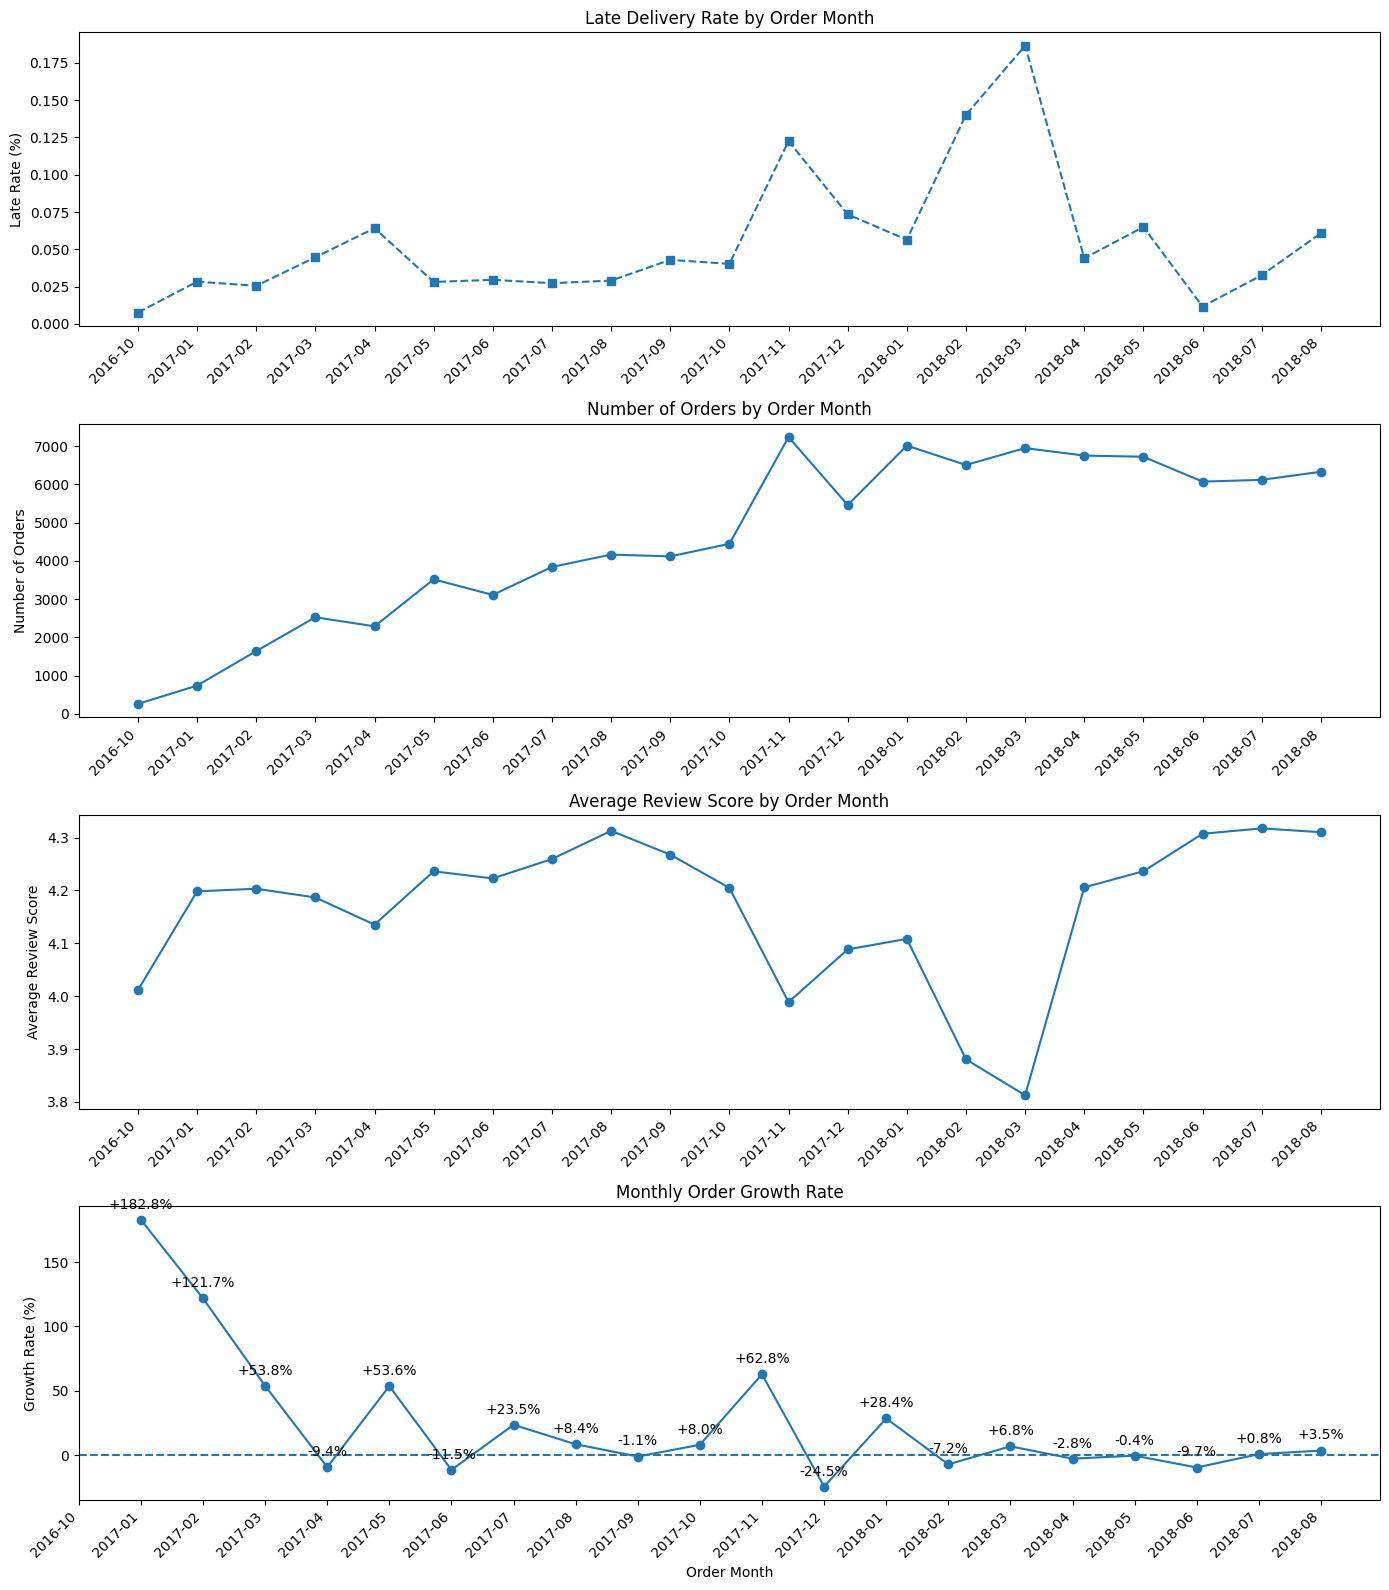

In [22]:
monthly["order_growth_rate"] = monthly["n_orders"].pct_change() * 100

fig, axes = plt.subplots(4, 1, figsize=(14, 16))

x = range(len(monthly))
labels = monthly["month"]

# 1. Late Delivery Rate
axes[0].plot(
    x,
    monthly["late_rate"],
    marker="s",
    linestyle="--"
)
axes[0].set_title("Late Delivery Rate by Order Month")
axes[0].set_ylabel("Late Rate (%)")

# 2. Number of Orders
axes[1].plot(
    x,
    monthly["n_orders"],
    marker="o"
)
axes[1].set_title("Number of Orders by Order Month")
axes[1].set_ylabel("Number of Orders")

# 3. Average Review Score
axes[2].plot(
    x,
    monthly["avg_review"],
    marker="o"
)
axes[2].set_title("Average Review Score by Order Month")
axes[2].set_ylabel("Average Review Score")

# 4. Order Growth Rate
axes[3].plot(
    x,
    monthly["order_growth_rate"],
    marker="o"
)
axes[3].axhline(0, linestyle="--")
axes[3].set_title("Monthly Order Growth Rate")
axes[3].set_ylabel("Growth Rate (%)")
axes[3].set_xlabel("Order Month")

# Growth rate labels
for i, y in enumerate(monthly["order_growth_rate"]):
    if pd.notna(y):
        axes[3].annotate(
            f"{y:+.1f}%",
            (i, y),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center"
        )

# X-axis labels
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right"
    )

plt.tight_layout()
plt.show()

In [23]:
from scipy import stats

on_time_scores = delivered.loc[~delivered['is_late'], 'review_score']
late_scores = delivered.loc[delivered['is_late'], 'review_score']

t_stat, p_val = stats.ttest_ind(on_time_scores, late_scores, equal_var=False)
print(f"Welch's t-test (on-time vs late review scores): t={t_stat:.2f}, p={p_val:.2e}")

Welch's t-test (on-time vs late review scores): t=100.79, p=0.00e+00


These analysis indicates that delivery performance and review scores are consistently linked. Late deliveries make up a small share of completed orders (6.7%), yet they carry a disproportionate share of dissatisfaction: on-time orders average a review score of 4.21 against 2.26 for late ones, a gap confirmed statistically significant by the Welch's t-test above (p < 0.001) rather than assumed from the raw numbers alone. A large share of late orders result in the lowest rating (1-star). This pattern is consistent across the dataset's full timespan (month-over-month, correlation of -0.77 between monthly late rate and monthly average review score), not just in isolated batches, meaning it's a structural relationship, not noise.

### **1.1.1 The Problem with Olist's Average 4.01 Rating**

Before treating customer satisfaction as a priority, it is necessary to determine whether Olist's 4.01/5 average review score represents a true operational weakness or merely an acceptable industry baseline. Evaluating this requires separating into two distinct issues which is whether 4.01 is objectively low compared to e-commerce benchmarks, and whether it negatively impacts Olist's financial performance despite the platform's ongoing order growth during the period analyzed.

PowerReviews [1] analyzed over 25.4 million product pages across more than 3,600 retailer and brand sites, found the average e-commerce product rating sits around 4.5 stars. Separately, research from Northwestern University's Spiegel Research Center [5] found that shoppers are most likely to purchase from listings rated between 4.2 and 4.5, then conversion starts to decline again as ratings approach a suspiciously perfect 5.0. Olist's 4.01 sits just below this commonly observed range. This means that this gap indicates that Olist is losing potential sales where customers visiting the platform are less likely to finalize their purchases compared to competitors operating within the industry standard.

Though Olist's growth have not actualy stalled from 2016-2018 (can be shown directly from the dataset itself). Monthly order volume grew from just 324 orders in October 2016 to over 7,000 orders per month by early-to-mid 2018 (the single-digit counts at the very start and end of the range are incomplete partial months at the edge of data collection, not real activity) roughly a 20x increase while the average review score held steady around 4.0-4.2. 

This still matters because growth and efficiency are two different metrics. A platform can continuously scale its order volume while continuing to lose measurable value to a fixable, quantifiable inefficiency

- The preliminary analysis shows that within Olist's own data, late deliverey orders average a review score of 2.26 whereas on-time deliveries averages 4.21.

- Unlike whatever combination of factors actually drove that 20x order-volume growth (which this dataset cannot fully explain, since it likely involves seller acquisition, marketing, or market expansion outside what these tables record), late-delivery risk is something operations can directly act on using data already being collected.

- Olist's order volume grew substantially throughout the period, but its monthly growth rate was not consistently increasing. For example, order growth reached +62.2% in November 2017, before dropping to -27.2% in December 2017. During this same peak period, the higher order volume also coincided with a higher rate of late deliveries and lower review scores. This highlights how late deliveries can affect customer experience as Olist continues to scale.

- 6.7% of the roughly 100K orders in this dataset is already over 6,300 damaged customer experiences, and that absolute count grew right alongside the order volume itself across 2016-2018.

Improving Olist’s score from 4.01 toward 4.5 offers direct financial benefits beyond the initial conversion gains. Michael Luca's Harvard Business School study of Yelp [6] found that a one-star increase in rating led to a 5-9% increase in revenue. Though this study is about local businesses on Yelp and not an e-commerce marketplace, the underlying mechanism applies universally. For instance, when buyers cannot physically inspect product quality prior to purchase, aggregated historical ratings serve as the primary signal of trust. For Olist’s customers, star ratings serve as a visible shortcut to judge a seller's trustworthiness. Additionally, a better rating is expected to increase sales volume, though the exact impact will depend on e-commerce market trends.

What does not necessarily transfer is the exact size of the effect. The 5-9% figure came from a market where competition is often local and geographically limited (choosing near restaurants), whereas Olist customers can typically choose among thousands of listings, a difference that plausibly changes the magnitude of the effect even if its direction holds. This is why the earlier PowerReviews [3] and Spiegel Research Center [5] findings matter alongside Luca's study [6] wven though it is in a different domain but proves the relationship is causal not just coincidental.

This relationship directly reflects Olist’s business model, which relies on taking a commission fee from each merchant sale. Higher platform ratings improve conversion rates on seller listings, leading to more completed transactions and higher total revenue for Olist. Ultimately, resolving the delivery delays that drive negative reviews creates operational efficiency by lowering costs associated with refunds, customer service inquiries, and order cancellations.

## **1.2 Problem Statement**
Late deliveries make up only 6.7% of Olist's orders, yet they are associated with a review score that collapses from 4.21 to 2.26 so how can a machine learning model predict, early enough for Operations to act, which orders are at risk of late delivery, so Olist can intervene proactively and protect the customer satisfaction that late delivery reliably damages?

## **1.3 Key Objectives**

1. **Identify and characterize the factors behind late delivery**: analyze order, seller, customer, product, and logistics-related factors (e.g. which sellers, regions, shipping distances, or product categories show elevated late-delivery rates) so the problem can be localized and explained, not treated as random noise.

2. **Quantify the satisfaction cost of lateness**: translate "late" into a measurable drop in review score (and, by extension, into churn risk), so the business impact is stated in evidence rather than left anecdotal.

3. **Build a predictive risk model usable within a real intervention window**: develop a classification model that flags an order's late-delivery risk at, or shortly after, order approval (not just after the fact), so the prediction arrives early enough for operations to realistically act on it.

4. **Establish an evaluation framework aligned with business cost, not just statistical accuracy**: given the class imbalance in late vs. on-time orders, a naive "always predict on-time" model can score deceptively high on accuracy while catching zero real risk. (Objectives around metric selection and success criteria exist specifically to avoid that trap.)

5. **Translate the High Risk flag into a concrete, internal operational lever**: since Olist does not control fulfillment directly, the flag is designed to be actioned by routing High Risk orders to Operations, who relay a prioritization notice to the responsible seller, not by contacting the customer. 

6. **Estimate the range of plausible business impact given that seller compliance is unknown before deployment**: since Olist cannot yet measure how often a notified seller will actually act on a High Risk flag, this project estimates the expected review-score impact across a swept range of compliance assumptions rather than committing to a single unproven number.

**Key stakeholder: Operations & Logistics Team**.  These findings and this model are built for them to help them identify the drivers
behind delays, detect high-risk orders earlier, and prioritize proactive action to protect delivery performance and customer satisfaction.


## **1.4 Analytical Approach**

The analytical approach for this project consists of several systematic stages:

| **Stage** | **Implementation** |
|---|---|
| Data Understanding | Understand the structure and characteristics of the dataset, while identifying potential data issues such as inconsistencies, missing values, and anomalies. |
| Exploratory Data Analysis (EDA) | Conduct descriptive analysis and data visualization to identify patterns, relationships between variables, and factors associated with late delivery. |
| Data Preprocessing | Prepare and clean the data by handling missing values, outliers, categorical variables, and other data quality issues before modeling. |
| Feature Engineering | Create relevant features and transform existing variables to better represent the factors that may contribute to late delivery and improve model performance. |
| Modeling | Experiment with several machine learning algorithms to develop a binary classifier that flags each order as High Risk or Low Risk of late delivery. |
| Model Evaluation | Evaluate model performance using metrics that are appropriate for the prediction objective and aligned with the business problem, and select a single operating threshold. |
| Impact Simulation | Translate the High Risk flag into an estimated business outcome (expected average review score among flagged orders) across a swept range of seller-compliance assumptions, since actual compliance can only be measured after deployment. |
| Business Recommendation | Translate the EDA findings, model results, and simulated impact into actionable insights that can help Olist's Operations team identify and route high-risk orders to sellers, and improve delivery performance. |

## **1.5 Metric Evaluation**

Because late vs. on-time orders are heavily imbalanced (Section 1.1 established late deliveries at only ~6.5% of orders), this project uses **PR-AUC (Precision-Recall Area Under the Curve)** as the primary metric for comparing candidate models during training, rather than accuracy or ROC-AUC. The chart below shows this imbalance directly on the data used for modeling.

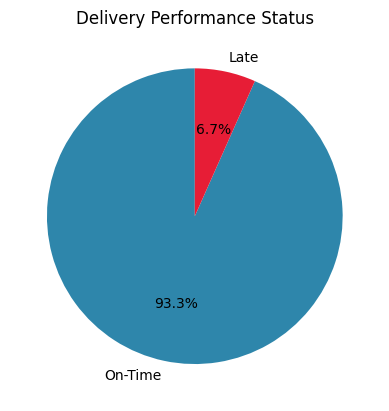

In [24]:
delivered["is_late"].value_counts().plot.pie(
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#2E86AB', '#e71d36'],
    labels=['On-Time', 'Late'] 
)

plt.title('Delivery Performance Status')
plt.ylabel('')
plt.show()

**What is PR-AUC?**  
PR-AUC is an evaluation metric that measures a classification model's performance by calculating the area under the curve formed by plotting precision against recall at various decision thresholds. It is widely favored for imbalanced data because it focuses heavily on the minority positive class without being inflated by a large number of true negatives.

**Why PR-AUC over ROC-AUC?**  
- **Ignores true negatives**: PR-AUC is built entirely from precision and recall, so true negatives (correctly predicted on-time orders, which dominate this dataset) never enter the calculation [16].
- **Prevents overoptimistic scores**: in a highly imbalanced dataset like this one, the false positive rate that drives ROC-AUC can stay deceptively small even when the model performs poorly on the minority (late) class, making ROC-AUC look better than the model actually deserves [17].
- **Stays sensitive to false positives**: precision directly punishes false positives relative to true positives, so as false alarms grow, precision (and therefore PR-AUC) drops sharply, exposing the model's real error rate on the class that actually matters here [18].

### **1.5.1 Business Cost of Misclassification**

This section works out what a **False Positive** (an order flagged High Risk that turns out fine) and a **False Negative** (a genuinely late order the model misses) actually cost Olist, using real-world precedent and published cost benchmarks, since Olist's own internal support/logistics cost figures are not available in this dataset.

**False Positive cost.** The single action taken on a flagged order is an internal, automated notification sent to the responsible seller through WhatsApp, asking them to prioritize packing and dispatch for that specific order. WhatsApp is Brazil's dominant business-messaging channel, making it a realistic, low-friction delivery mechanism for this kind of internal alert. Meta's own published 2026 utility-message rate for Brazil is **R\$0.049 per delivered message** [19], which closely matches this project's working estimate of **R\$0.04-0.05 per notification**. At a monthly volume of roughly 10,000 flagged orders, this is only **R\$400-490 (≈US\$78-96) per month** a small, predictable operating cost regardless of how many of those flags turn out to be false alarms.

This aligns directly with standard marketplace operations. Walmart's Seller Performance Standards program [15] and Amazon's Performance Notifications tool [14] both automatically alert sellers when an order-level metric (like on-time delivery rate) is at risk, and require the seller to take corrective action or face consequences. Olist's flag follows the same pattern, just applied at the level of a single order instead of an account-wide metric.

**False Negative cost.** If a genuinely late order is not flagged, it receives no notification, so the seller has no reason to prioritize it. The realistic consequence is that the customer discovers the delay on their own and contacts support reactively, and Olist typically offers a reactive compensation voucher or partial refund to manage the complaint:

| # | Cost component | Benchmark used | Estimated cost (BRL) |
|---|---|---|---|
| 1 | **Reactive customer support contact**. The customer contacts support about a late order (call, chat, or message) after the fact, requiring a human agent to follow up | E-commerce customer support averages **US\$2.70-\$5.60 per contact** (cross-industry benchmark [11], corroborated by multiple independent 2025-2026 sources) | **≈R\$14-29** |
| 2 | **Reactive compensation voucher or partial refund**. Issued after the fact to manage the complaint | Shopee's On-Time Guarantee benchmark of RM5.00 (≈US\$1) [9] and Gojek's SafeTrip+ guarantee [10] both confirm small, standardized post-hoc compensation is routine industry practice for a broken delivery promise -- Olist could reasonably set this higher given a higher average order value | **≈R\$15-25** (illustrative) |
| 3 | **Full order reimbursement**. Reserved for the worst-case escalation where the customer disputes the charge entirely | Olist's own established average order value from this project's EDA | **≈R\$161 (ceiling, not the expected case)** |

None of these are Olist's confirmed internal costs. They are estimates built from published industry benchmarks and this project's own EDA figures, intended to establish the *relative* size and *direction* of the cost asymmetry, not to serve as an exact budget.

$$\text{Estimated FN cost} \approx R\$14\text{-}29 + R\$15\text{-}25 \approx \textbf{R\$30-55 per missed late order}$$

$$\text{Estimated FP cost} \approx \textbf{R\$0.04-0.05 per false alarm (single WhatsApp notification)}$$

Missing a genuinely late order is now roughly **600-1,000x** more expensive than a false alarm on the notification mechanism. Taken at face value, this ratio would argue for optimizing almost purely for recall and accepting low precision, since a false alarm costs next to nothing.

However in this project, we do not actually aim to do that. A model tuned to flag nearly everything would technically minimize expected cost, but it would defeat the purpose of the flag. If Operations and sellers see High Risk notifications on orders that are usually fine, they will start ignoring them, and the mechanism stops working long before the cost math would predict a problem. This is why precision is kept as an explicit guardrail in the metric choice below, and why the actual operating threshold is tuned post-training against the observed precision-recall trade-off rather than set purely from the FP:FN cost ratio.

Beyond the baseline financial costs incurred from sending unnecessary notifications or failing to predict late deliveries accurately, we must examine a critical behavioral variable: the **"cry wolf" effect**. 

The "cry wolf" effect is a documented psychological and behavioral phenomenon wherein repeated false alarms diminish user trust, ultimately leading to delayed responses or complete disregard during a genuine emergency [20]. Rooted in Aesop’s classic fable, this phenomenon dictates that continuous exposure to unmaterialized warnings desensitizes individuals. Over time, users normalize the hazard and dismiss subsequent alerts as background noise. 

In our context, treating this threshold as static ignores the reality that a poorly calibrated model will actively degrade seller engagement, compounding the financial risks calculated previously.


Empirical research indicates that this desensitization severely impairs preparedness and efficiency during natural disasters, such as floods [21]. Similarly, within healthcare environments, "alarm fatigue" is recognized as a significant risk to both patient safety and the well-being of healthcare professionals (HCPs) [22]. 

This phenomenon directly applies to our current framework, specifically regarding the notification system that alerts sellers when an order is at high risk of delayed fulfillment. These notifications urge sellers to expedite package handovers to the respective Olist logistics partner. Because this system functions strictly as an alert mechanism, it operates under the same psychological constraints as a traditional alarm. Therefore, it is critical to evaluate whether our model successfully minimizes the "cry wolf" effect. If the model generates excessive false positives, sellers may begin to disregard the alerts, ultimately rendering the intervention ineffective. 

To quantify the financial impact of a seller ignoring notifications, we cannot simply assign an arbitrary threshold. Instead, we must calculate the cost ratio. As demonstrated by Charles Elkan [23], it is impossible to determine whether a predictive model outperforms a baseline "all-notification" strategy without rigorous empirical testing. Following Elkan's methodology, the cost ratio is defined by the following formula: 
$$\text{Cost Ratio} = \frac{C_{FP}}{C_{FN}}$$

Where:
*   **$C_{FN}$ (Cost of a False Negative / Miss):** The financial penalty incurred when an order is delayed without a prior warning sent to the seller (e.g., costs associated with order refunds, negative customer reviews, and additional customer support time). 
*   **$C_{FP}$ (Cost of a False Positive / False Alarm):** The operational friction penalty generated by a redundant or inaccurate notification.

To effectively apply this formula, we must establish the specific threshold of false alarms that triggers a seller to disregard notifications. Behavioral research indicates that humans operate with a short-term memory buffer; if an automated system triggers three to four false alarms in immediate succession, user trust drops to near-zero [24]. Consequently, the user is highly likely to mute, disable, or consciously ignore the system for the remainder of their session. Conversely, trust gradually resets if a true alarm occurs or if the system remains silent for an extended period. 

If we establish that three to four false alarms generate enough operational friction to equal the damage of a single missed late delivery, the relationship can be expressed mathematically as:

$$C_{FP} = \frac{1}{3} \times C_{FN}$$

Applying this to our framework, if the cost of a missed late delivery ($C_{FN}$) is **\$42.50**, then the real-world cost of a false alarm ($C_{FP}$) is **\$14.17** per spam alert.


### **1.5.2 Machine Learning Metrics**

Given the class imbalance already established above (roughly 6.7% of orders are late), a model that always predicts "on-time" would score above 90% accuracy while catching zero real risk which a deceptively good looking number that provides zero business value. This alone rules out accuracy as the metric this project optimizes for.

| Metric | Why it is used here |
|---|---|
| **PR-AUC** | The primary metric for comparing models during training because it stays honest about performance on the rare positive (late) class instead of being inflated by the volume of true negatives. |
| **Recall** | Since a missed late order (FN) costs roughly two to three orders of magnitude more than a false alarm on the notification mechanism, recall is prioritized over precision. |
| **Precision** | If the vast majority of High Risk flags turn out fine, Operations and sellers may start ignoring the notification altogether, which would defeat the purpose regardless of how cheap each individual false alarm is. |
| **F2 Score** | A single number that combines precision and recall but deliberately weights recall higher, used as a secondary headline metric once a threshold is selected. |

### **1.5.3 Operational Strategy: Post-Training Threshold Tuning**

By prioritizing **PR-AUC** during the machine learning training phase, the model is optimized to separate late from on-time orders as well as possible across all thresholds, before any single cutoff is chosen.

Instead of relying on Python's default 50% classification cutoff, we extract raw probabilities via `.predict_proba()` and apply **threshold tuning** at deployment to match the intervention recommendation constrant:

1. **Aggressive identification (maximize recall)**: We will prioritize maximizing recall to capture as many late orders as possible, ensuring that late-delivery risks do not go undetected.

2. **False alarm mitigation (protect precision)**: Simultaneously, we will establish strict thresholds to control the false alarm rate, striking an optimal balance so that the model does not trigger excessive false positives.


## **1.6 Success Criteria**

* **Customer Satisfaction Recovery:** Target a 30% improvement in average review scores for at-risk orders by intervention late delivery orders. 

* **PR-AUC Target ($\ge 0.20$):** This is set relative to this dataset's own positive-class base rate (6.7%), since a model with no real signal would score PR-AUC roughly equal to that base rate. a floor of 0.20 is roughly 3x the base rate, a defensible bar for "the model is finding real signal," without assuming a specific ceiling this project hasn't yet observed.

* **High-Recall Target ($\ge 60\%$):** Given the extreme cost asymmetry where a False Negative (missed late order costing $\text{R}\$30\text{--}55$) outweighs a False Positive (WhatsApp alert costing $\text{R}\$0.045$) by $\approx 600\text{--}1,000\times$, the model must prioritize capturing the vast majority of genuinely late orders.

* **Operational Precision Guardrail ($\ge 13\%$):** Set a minimum precision floor to prevent severe seller "alert fatigue." While recall is prioritized for cost optimization, precision must remain high enough that sellers do not completely ignore automated notifications.

* **Strict Non-Leakage Data Scope:** Build and evaluate the model using exclusively order approval-time features available at `order_approved_at`, ensuring no downstream shipping or delivery timestamps leak into production scoring.

* **Temporal Validation Stability:** Validate model performance using time-based splits (`TimeSeriesSplit`) rather than random k-fold cross-validation, ensuring predictions remain reliable across seasonal volume spikes and holiday surges.


## **1.7 References**

1. Gopinadh, A. V. S. S., Sarma, S. V. S. N., & Radhesyam, G. (2026). Customer satisfaction prediction in online goods delivery through interpretable predictive models and sentiment analysis. In A. Kumar & S. Mozar (Eds.), Proceedings of the 7th International Conference on Communications and Cyber Physical Engineering (ICCCE 2024), Lecture Notes in Electrical Engineering, vol. 1466, pp. 1015-1025. Springer, Singapore. https://doi.org/10.1007/978-981-95-0269-1_114

2. Wangkiat, P., & Polprasert, C. (2023). Machine learning approach to predict e-commerce customer satisfaction score. IEEE conference https://ieeexplore.ieee.org/document/10147542/

3. Mahdjoub Mohammed Bachir, Zohra, F., Laallam Professor, Messaoud Mezati and Djouhri Ahlam (2024). Enhancing Customer Satisfaction using Machine Learning. Brazilian Journal of Technology, 7(4), pp.1-20. doi:10.38152/bjtv7n4-011.

4. PowerReviews. (2022). Ratings & Reviews Benchmarks: Average Rating. Based on an analysis of 25.4M+ product pages across 3,600+ retailer and brand sites.

5. Northwestern University, Spiegel Research Center. How Online Reviews Influence Sales.

6. Luca, M. (2011, rev. 2016). Reviews, reputation, and revenue: The case of Yelp.com. Harvard Business School Working Paper No. 12-016.

7. Hien, N. N., et al. (2024). Customer responses to airline service failure: Perspectives from expectation disconfirmation theory. Journal of Service Theory and Practice, SAGE.

8. (2024). Finding the sweet spots: Optimizing compensation in proactive service recovery. Journal of Consumer Satisfaction, Dissatisfaction and Complaining Behavior.

9. Shopee Malaysia. (2024). On-Time Guarantee Programme. As reported in: Is your Shopee delivery late? Here's how to redeem a free voucher. Malay Mail, May 7, 2024. https://malaymail.com/news/life/2024/05/07/is-your-shopee-delivery-late-heres-how-to-redeem-a-free-voucher/132923

10. Gojek. On-Time Pickup Guarantee Voucher for GoRide and GoCar (SafeTrip+). https://www.gojek.com/en-id/help/gocar/voucher-jaminan-jemput-tepat-waktu-untuk-goride-dan-gocar

11. LiveChatAI. (2025). The True Cost of Customer Support: 2025 Analysis Across 50 Industries. https://livechatai.com/blog/customer-support-cost-benchmarks

12. ShipperHQ. Expedited vs Standard Shipping: Which is Better for E-commerce? https://shipperhq.com/blog/expedited-vs-standard-shipping-for-ecommerce

13. Elkan, C. (2001). The foundations of cost-sensitive learning. In Proceedings of the Seventeenth International Joint Conference on Artificial Intelligence (IJCAI'01), pp. 973-978.

14. Marketplace Valet. (2024). How to Use Amazon's Performance Notifications Tool: A Guide for Sellers. https://marketplacevalet.com/how-to-use-amazons-performance-notifications-tool-a-guide-for-sellers/

15. Walmart Marketplace / SupplierWiki. (2025). Walmart Marketplace Performance Standards. https://supplierwiki.supplypike.com/articles/walmart-marketplace-performance-standards

16. Sofaer, H. R., Hoeting, J. A., & Jarnevich, C. S. (2019). The area under the precision-recall curve as a performance metric for rare binary events. Methods in Ecology and Evolution, 10(4), 565-577. https://besjournals.onlinelibrary.wiley.com/doi/10.1111/2041-210X.13140

17. Imani, M., Joudaki, M., Bagheri, A., & Arabnia, H. R. (2026). Why ROC-AUC Is Misleading for Highly Imbalanced Data: In-Depth Evaluation of MCC, F2-Score, H-Measure, and AUC-Based Metrics Across Diverse Classifiers. Technologies, 14(1), 54. https://www.mdpi.com/2227-7080/14/1/54

18. Hancock, J. T., Khoshgoftaar, T. M., & Johnson, J. M. (2023). Evaluating classifier performance with highly imbalanced Big Data. Journal of Big Data, 10(1). https://www.researchgate.net/publication/369945821_Evaluating_classifier_performance_with_highly_imbalanced_Big_Data

19. Message Central. (2026). WhatsApp Business API Pricing in Brazil 2026: Real Cost Breakdown by Volume. https://www.messagecentral.com/blog/whatsapp-business-api-pricing-in-brazil

20. Rahime, D. A., Homri, L., Boeuf, T., Dantan, J.-Y., & Bonnet, F. (2026). Quantifying and mitigating alarm fatigue caused by fault detection systems. Reliability Engineering & System Safety, 267, 111890. https://doi.org/10.1016/j.ress.2025.111890

21. Sawada, Y., Kanai, R., & Kotani, H. (2022). Impact of cry wolf effects on social preparedness and the efficiency of flood early warning systems. Hydrology and Earth System Sciences, 26(16), 4265–4278. https://doi.org/10.5194/hess-26-4265-2022

22. Michels, E. A. M., Gilbert, S., Koval, I., & Wekenborg, M. K. (2025). Alarm fatigue in healthcare: a scoping review of definitions, influencing factors, and mitigation strategies. BMC Nursing, 24(1). https://doi.org/10.1186/s12912-025-03369-2

23. Elkan, C. (2001). The Foundations of Cost-Sensitive Learning. https://cseweb.ucsd.edu/~elkan/rescale.pdf

24. Chancey, E. T., Bliss, J. P., Liechty, M., & Proaps, A. B. (2015). False Alarms vs. Misses. Proceedings of the Human Factors and Ergonomics Society Annual Meeting, 59(1), 647–651. https://doi.org/10.1177/1541931215591141